# NBA Player Peak Analysis

This notebook analyzes when NBA players reach their performance peak using advanced metrics (PER, BPM, VORP, WS, WS/48).

**Key Questions:**
- At what age do players typically peak?
- How does peak age vary by talent tier?
- How do aging curves differ across metrics?
- Are peaks robust to different filtering and smoothing approaches?

**Outputs:**
- Peak age summaries by tier and era
- Aging curve visualizations with confidence intervals
- Robustness checks on filters and smoothing

## 1. Setup and Load

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Define paths
DATA_DIR = Path("../data")
CLEAN_DIR = DATA_DIR / "03-cleaned"
PEAK_DIR = DATA_DIR / "04-peak"
FIG_DIR = Path("../figures/peak")

# Ensure output directories exist
PEAK_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")

✓ Setup complete


In [2]:
# Load cleaned datasets
df_modern = pd.read_csv(CLEAN_DIR / "nba_modern_era_clean.csv")
df_per = pd.read_csv(CLEAN_DIR / "nba_per_era_clean.csv")
df_complete = pd.read_csv(CLEAN_DIR / "nba_complete_clean.csv")

print(f"Modern era: {len(df_modern):,} rows, {df_modern['player_name'].nunique():,} players")
print(f"PER era: {len(df_per):,} rows, {df_per['player_name'].nunique():,} players")
print(f"Complete: {len(df_complete):,} rows, {df_complete['player_name'].nunique():,} players")

# Display sample
df_modern.head(3)

Modern era: 10,596 rows, 1,468 players
PER era: 14,146 rows, 1,821 players
Complete: 14,632 rows, 1,821 players


,player_name,year_id,age,team_name_abbr,games,mp,per,bpm,vorp,ws,ws_per_48,era,mpg,dataset
0,A.C. Green,1993,29,LAL,82,2819.0,16.3,0.7,1.9,8.6,0.147,Full Advanced,34.378049,modern
1,A.C. Green,1994,30,PHO,82,2825.0,17.0,0.6,1.8,9.3,0.157,Full Advanced,34.451220,modern
2,A.C. Green,1995,31,PHO,82,2687.0,14.2,-0.1,1.3,6.7,0.120,Full Advanced,32.768293,modern


In [3]:
# Recompute MPG and apply season filters
def apply_season_filters(df, min_games=20, min_mpg=10):
    """Apply per-season filters: games >= 20 and MPG >= 10"""
    df = df.copy()
    
    # Recompute MPG to be safe
    df['mpg'] = df['mp'] / df['games']
    
    # Apply filters
    df_filtered = df[(df['games'] >= min_games) & (df['mpg'] >= min_mpg)].copy()
    
    print(f"Before filters: {len(df):,} rows")
    print(f"After filters:  {len(df_filtered):,} rows ({100*len(df_filtered)/len(df):.1f}%)")
    
    return df_filtered

# Apply filters to modern era data
df_modern_filtered = apply_season_filters(df_modern)

Before filters: 10,596 rows
After filters:  10,596 rows (100.0%)


In [4]:
# Apply career filters: >= 3 seasons and >= 82 total games
def apply_career_filters(df, min_seasons=3, min_total_games=82):
    """Keep only players with sufficient career length"""
    player_stats = df.groupby('player_name').agg({
        'games': 'sum',
        'year_id': 'count'
    }).rename(columns={'year_id': 'seasons'})
    
    valid_players = player_stats[
        (player_stats['seasons'] >= min_seasons) & 
        (player_stats['games'] >= min_total_games)
    ].index
    
    df_career_filtered = df[df['player_name'].isin(valid_players)].copy()
    
    print(f"Before career filters: {df['player_name'].nunique():,} players")
    print(f"After career filters:  {df_career_filtered['player_name'].nunique():,} players")
    print(f"  (>= {min_seasons} seasons, >= {min_total_games} total games)")
    
    return df_career_filtered

df_modern_filtered = apply_career_filters(df_modern_filtered)

Before career filters: 1,468 players
After career filters:  1,387 players
  (>= 3 seasons, >= 82 total games)


In [5]:
# Verify data types and era labels
print("Data types:")
print(f"  year_id: {df_modern_filtered['year_id'].dtype}")
print(f"  age: {df_modern_filtered['age'].dtype}")
print(f"  per: {df_modern_filtered['per'].dtype}")
print(f"  bpm: {df_modern_filtered['bpm'].dtype}")
print(f"  ws: {df_modern_filtered['ws'].dtype}")

print(f"\nEra distribution:")
print(df_modern_filtered['era'].value_counts())

print(f"\nYear range: {df_modern_filtered['year_id'].min()} - {df_modern_filtered['year_id'].max()}")
print(f"Age range: {df_modern_filtered['age'].min()} - {df_modern_filtered['age'].max()}")

# Assert key types
assert df_modern_filtered['year_id'].dtype in ['int64', 'int32'], "year_id should be integer"
assert pd.api.types.is_numeric_dtype(df_modern_filtered['age']), "age should be numeric"

Data types:
  year_id: int64
  age: int64
  per: float64
  bpm: float64
  ws: float64

Era distribution:
era
Full Advanced    10474
Name: count, dtype: int64

Year range: 1993 - 2025
Age range: 18 - 43


## 2. Filtering and Segmentation

In [6]:
# Define talent tier assignment function
def assign_talent_tier(row):
    """
    Assign talent tier based on BPM, WS, or PER thresholds (priority order).
    
    Tiers:
    - Elite: BPM >= 5 or WS >= 10 or PER >= 22
    - All-Star: BPM in [2,5) or WS in [6,10) or PER in [19,22)
    - Starter/Rotation: BPM in [0,2) or WS in [3,6) or PER in [15,19)
    - Role/Bench: Below all thresholds
    """
    # Priority 1: BPM
    if pd.notna(row['bpm']):
        if row['bpm'] >= 5:
            return "Elite"
        elif row['bpm'] >= 2:
            return "All-Star"
        elif row['bpm'] >= 0:
            return "Starter/Rotation"
        else:
            return "Role/Bench"
    
    # Priority 2: WS
    if pd.notna(row['ws']):
        if row['ws'] >= 10:
            return "Elite"
        elif row['ws'] >= 6:
            return "All-Star"
        elif row['ws'] >= 3:
            return "Starter/Rotation"
        else:
            return "Role/Bench"
    
    # Priority 3: PER
    if pd.notna(row['per']):
        if row['per'] >= 22:
            return "Elite"
        elif row['per'] >= 19:
            return "All-Star"
        elif row['per'] >= 15:
            return "Starter/Rotation"
        else:
            return "Role/Bench"
    
    # Default if all metrics are null
    return "Unknown"

# Apply talent tier assignment
df_modern_filtered['talent_tier'] = df_modern_filtered.apply(assign_talent_tier, axis=1)

print("Talent tier distribution:")
print(df_modern_filtered['talent_tier'].value_counts())
print(f"\nTotal player-seasons: {len(df_modern_filtered):,}")

Talent tier distribution:
talent_tier
Role/Bench          6181
Starter/Rotation    2574
All-Star            1345
Elite                374
Name: count, dtype: int64

Total player-seasons: 10,474


## 3. Peak Extraction (Raw and Smoothed)

In [7]:
# Add smoothed metrics using rolling mean
def add_smoothed(group, cols, w=3):
    """Add smoothed versions of specified columns using centered rolling mean"""
    group = group.sort_values('year_id').copy()
    
    for col in cols:
        if col in group.columns:
            smooth_col = f"{col}_smooth"
            group[smooth_col] = group[col].rolling(window=w, center=True, min_periods=1).mean()
    
    return group

# Apply smoothing to key metrics
metrics_to_smooth = ['per', 'bpm', 'ws', 'ws_per_48']
df_modern_smooth = df_modern_filtered.groupby('player_name', group_keys=False).apply(
    lambda g: add_smoothed(g, metrics_to_smooth, w=3)
)

print("Smoothed metrics added:")
smooth_cols = [c for c in df_modern_smooth.columns if c.endswith('_smooth')]
print(f"  {', '.join(smooth_cols)}")
print(f"\nDataframe shape: {df_modern_smooth.shape}")

# Display example for one player
example_player = "LeBron James"
if example_player in df_modern_smooth['player_name'].values:
    print(f"\nExample: {example_player} (raw vs smoothed BPM)")
    display(df_modern_smooth[df_modern_smooth['player_name'] == example_player][
        ['player_name', 'year_id', 'age', 'bpm', 'bpm_smooth']
    ].head(10))

Smoothed metrics added:
  per_smooth, bpm_smooth, ws_smooth, ws_per_48_smooth

Dataframe shape: (10474, 19)

Example: LeBron James (raw vs smoothed BPM)


,player_name,year_id,age,bpm,bpm_smooth
6394,LeBron James,2004,19,1.7,5.150000
6395,LeBron James,2005,20,8.6,6.466667
6396,LeBron James,2006,21,9.1,8.600000
6397,LeBron James,2007,22,8.1,9.366667
6398,LeBron James,2008,23,10.9,10.733333
6399,LeBron James,2009,24,13.2,11.966667
6400,LeBron James,2010,25,11.8,11.033333
6401,LeBron James,2011,26,8.1,10.266667
6402,LeBron James,2012,27,10.9,10.233333
6403,LeBron James,2013,28,11.7,10.466667


In [9]:
# Define peak selection functions
def pick_peak(group, metric):
    """
    Select peak season for a given metric.
    
    Returns series with peak_year, peak_age, peak_value.
    Tie-breaking: higher games, higher mpg, later year_id.
    """
    # Filter to non-null metric values
    valid = group[group[metric].notna()].copy()
    
    if len(valid) == 0:
        return pd.Series({
            'peak_year': np.nan,
            'peak_age': np.nan,
            'peak_value': np.nan
        })
    
    # Sort by metric (desc), games (desc), mpg (desc), year_id (desc)
    valid = valid.sort_values(
        by=[metric, 'games', 'mpg', 'year_id'],
        ascending=[False, False, False, False]
    )
    
    # Take first row (peak)
    peak = valid.iloc[0]
    
    return pd.Series({
        'peak_year': int(peak['year_id']),
        'peak_age': int(peak['age']),
        'peak_value': float(peak[metric])
    })

def compute_peaks(df, metric):
    """Compute peak statistics for all players for a given metric"""
    peaks = df.groupby('player_name').apply(
        lambda g: pick_peak(g, metric)
    ).reset_index()
    
    # Rename columns to include metric name
    peaks.columns = [
        'player_name',
        f'{metric}_peak_year',
        f'{metric}_peak_age',
        f'{metric}_peak_value'
    ]
    
    return peaks

print("✓ Peak selection functions defined")

✓ Peak selection functions defined


In [10]:
# Compute peaks for all metrics (raw and smoothed)
raw_metrics = ['per', 'bpm', 'ws', 'ws_per_48']
smooth_metrics = ['per_smooth', 'bpm_smooth', 'ws_smooth', 'ws_per_48_smooth']

all_metrics = raw_metrics + smooth_metrics

# Compute peaks for each metric
peak_dfs = []
for metric in all_metrics:
    print(f"Computing peaks for {metric}...")
    peak_df = compute_peaks(df_modern_smooth, metric)
    peak_dfs.append(peak_df)

# Merge all peak dataframes
player_peaks = peak_dfs[0]
for peak_df in peak_dfs[1:]:
    player_peaks = player_peaks.merge(peak_df, on='player_name', how='outer')

print(f"\n✓ Computed peaks for {len(all_metrics)} metrics")
print(f"✓ {len(player_peaks):,} players in peak table")
print(f"\nColumns: {player_peaks.shape[1]}")
player_peaks.head()

Computing peaks for per...
Computing peaks for bpm...
Computing peaks for ws...
Computing peaks for ws_per_48...
Computing peaks for per_smooth...
Computing peaks for bpm_smooth...
Computing peaks for ws_smooth...
Computing peaks for ws_per_48_smooth...

✓ Computed peaks for 8 metrics
✓ 1,387 players in peak table

Columns: 25


,player_name,per_peak_year,per_peak_age,per_peak_value,bpm_peak_year,bpm_peak_age,bpm_peak_value,ws_peak_year,ws_peak_age,ws_peak_value,...,per_smooth_peak_value,bpm_smooth_peak_year,bpm_smooth_peak_age,bpm_smooth_peak_value,ws_smooth_peak_year,ws_smooth_peak_age,ws_smooth_peak_value,ws_per_48_smooth_peak_year,ws_per_48_smooth_peak_age,ws_per_48_smooth_peak_value
0,A.C. Green,1994.0,30.0,17.0,1993.0,29.0,0.7,1994.0,30.0,9.3,...,16.650000,1993.0,29.0,0.650000,1993.0,29.0,8.950000,1993.0,29.0,0.152000
1,A.J. Price,2010.0,23.0,14.0,2010.0,23.0,-0.5,2013.0,26.0,2.2,...,12.350000,2013.0,26.0,-1.000000,2015.0,28.0,1.250000,2013.0,26.0,0.062667
2,Aaron Brooks,2010.0,25.0,16.0,2010.0,25.0,0.7,2010.0,25.0,5.5,...,14.000000,2009.0,24.0,-0.133333,2009.0,24.0,3.500000,2008.0,23.0,0.099000
3,Aaron Gordon,2023.0,27.0,19.5,2023.0,27.0,2.1,2024.0,28.0,7.1,...,17.766667,2024.0,28.0,1.533333,2023.0,27.0,6.366667,2024.0,28.0,0.149667
4,Aaron Gray,2008.0,23.0,13.9,2009.0,24.0,-3.4,2012.0,27.0,1.4,...,12.700000,2008.0,23.0,-3.450000,2011.0,26.0,1.266667,2011.0,26.0,0.089333


In [11]:
# Add era and talent tier to player peaks table
# Use the player's highest tier season and their era
player_info = df_modern_smooth.groupby('player_name').agg({
    'era': 'first',  # All should be same era in modern data
    'talent_tier': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

player_peaks_modern = player_peaks.merge(player_info, on='player_name', how='left')

# Reorder columns for better readability
col_order = ['player_name', 'era', 'talent_tier']
col_order += [c for c in player_peaks_modern.columns if c not in col_order]
player_peaks_modern = player_peaks_modern[col_order]

print(f"Final player_peaks_modern shape: {player_peaks_modern.shape}")
print(f"\nTalent tier distribution in peak table:")
print(player_peaks_modern['talent_tier'].value_counts())

player_peaks_modern.head()

Final player_peaks_modern shape: (1387, 27)

Talent tier distribution in peak table:
talent_tier
Role/Bench          1013
Starter/Rotation     195
All-Star             145
Elite                 34
Name: count, dtype: int64


,player_name,era,talent_tier,per_peak_year,per_peak_age,per_peak_value,bpm_peak_year,bpm_peak_age,bpm_peak_value,ws_peak_year,...,per_smooth_peak_value,bpm_smooth_peak_year,bpm_smooth_peak_age,bpm_smooth_peak_value,ws_smooth_peak_year,ws_smooth_peak_age,ws_smooth_peak_value,ws_per_48_smooth_peak_year,ws_per_48_smooth_peak_age,ws_per_48_smooth_peak_value
0,A.C. Green,Full Advanced,Role/Bench,1994.0,30.0,17.0,1993.0,29.0,0.7,1994.0,...,16.650000,1993.0,29.0,0.650000,1993.0,29.0,8.950000,1993.0,29.0,0.152000
1,A.J. Price,Full Advanced,Role/Bench,2010.0,23.0,14.0,2010.0,23.0,-0.5,2013.0,...,12.350000,2013.0,26.0,-1.000000,2015.0,28.0,1.250000,2013.0,26.0,0.062667
2,Aaron Brooks,Full Advanced,Role/Bench,2010.0,25.0,16.0,2010.0,25.0,0.7,2010.0,...,14.000000,2009.0,24.0,-0.133333,2009.0,24.0,3.500000,2008.0,23.0,0.099000
3,Aaron Gordon,Full Advanced,Starter/Rotation,2023.0,27.0,19.5,2023.0,27.0,2.1,2024.0,...,17.766667,2024.0,28.0,1.533333,2023.0,27.0,6.366667,2024.0,28.0,0.149667
4,Aaron Gray,Full Advanced,Role/Bench,2008.0,23.0,13.9,2009.0,24.0,-3.4,2012.0,...,12.700000,2008.0,23.0,-3.450000,2011.0,26.0,1.266667,2011.0,26.0,0.089333


## 4. Summaries and Visualizations

### 4.1 Peak Age Summary Tables

In [12]:
# Compute peak age summaries by talent tier
def summarize_peak_ages_by_group(df, group_col, peak_age_cols):
    """Compute summary statistics for peak ages by a grouping variable"""
    results = []
    
    for metric_col in peak_age_cols:
        metric_name = metric_col.replace('_peak_age', '')
        
        for group_val in df[group_col].dropna().unique():
            group_data = df[df[group_col] == group_val][metric_col].dropna()
            
            if len(group_data) > 0:
                results.append({
                    group_col: group_val,
                    'metric': metric_name,
                    'count': len(group_data),
                    'median': group_data.median(),
                    'mean': group_data.mean(),
                    'std': group_data.std(),
                    'q1': group_data.quantile(0.25),
                    'q3': group_data.quantile(0.75),
                    'iqr': group_data.quantile(0.75) - group_data.quantile(0.25)
                })
    
    return pd.DataFrame(results)

# Get all peak age columns
peak_age_cols = [c for c in player_peaks_modern.columns if c.endswith('_peak_age')]

# Summary by talent tier
summary_by_tier = summarize_peak_ages_by_group(
    player_peaks_modern, 
    'talent_tier', 
    peak_age_cols
)

print("Peak Age Summary by Talent Tier:")
display(summary_by_tier.sort_values(['talent_tier', 'metric']))

# Save to CSV
summary_by_tier.to_csv(PEAK_DIR / "peak_age_summary_by_tier.csv", index=False)
print(f"\n✓ Saved to {PEAK_DIR / 'peak_age_summary_by_tier.csv'}")

Peak Age Summary by Talent Tier:


,talent_tier,metric,count,median,mean,std,q1,q3,iqr
6,All-Star,bpm,145,26.0,26.593103,3.298772,24.00,29.00,5.00
22,All-Star,bpm_smooth,145,26.0,26.793103,3.120044,24.00,29.00,5.00
2,All-Star,per,145,26.0,26.565517,3.148663,24.00,28.00,4.00
18,All-Star,per_smooth,145,26.0,26.606897,3.120934,24.00,29.00,5.00
10,All-Star,ws,145,26.0,26.200000,2.992119,24.00,28.00,4.00
14,All-Star,ws_per_48,145,26.0,26.613793,3.407888,24.00,29.00,5.00
30,All-Star,ws_per_48_smooth,145,26.0,26.489655,3.405709,24.00,29.00,5.00
26,All-Star,ws_smooth,145,26.0,26.200000,3.060955,24.00,28.00,4.00
7,Elite,bpm,34,27.0,26.529412,2.820222,24.00,29.00,5.00
23,Elite,bpm_smooth,34,26.5,26.411765,2.753704,24.25,28.00,3.75



✓ Saved to ../data/04-peak/peak_age_summary_by_tier.csv


In [13]:
# Summary by era
summary_by_era = summarize_peak_ages_by_group(
    player_peaks_modern,
    'era',
    peak_age_cols
)

print("Peak Age Summary by Era:")
display(summary_by_era.sort_values(['era', 'metric']))

# Save to CSV
summary_by_era.to_csv(PEAK_DIR / "peak_age_summary_by_era.csv", index=False)
print(f"\n✓ Saved to {PEAK_DIR / 'peak_age_summary_by_era.csv'}")

Peak Age Summary by Era:


,era,metric,count,median,mean,std,q1,q3,iqr
1,Full Advanced,bpm,1387,26.0,26.083634,3.222206,24.0,28.0,4.0
5,Full Advanced,bpm_smooth,1387,26.0,26.081471,3.196295,24.0,28.0,4.0
0,Full Advanced,per,1387,26.0,25.927181,3.146913,24.0,28.0,4.0
4,Full Advanced,per_smooth,1387,25.0,25.831291,3.088932,24.0,28.0,4.0
2,Full Advanced,ws,1387,26.0,25.898342,3.113841,24.0,28.0,4.0
3,Full Advanced,ws_per_48,1387,26.0,26.113915,3.380190,24.0,28.0,4.0
7,Full Advanced,ws_per_48_smooth,1387,26.0,26.071377,3.338301,24.0,28.0,4.0
6,Full Advanced,ws_smooth,1387,26.0,25.814708,3.062054,24.0,28.0,4.0



✓ Saved to ../data/04-peak/peak_age_summary_by_era.csv


### 4.2 Peak Age Distributions

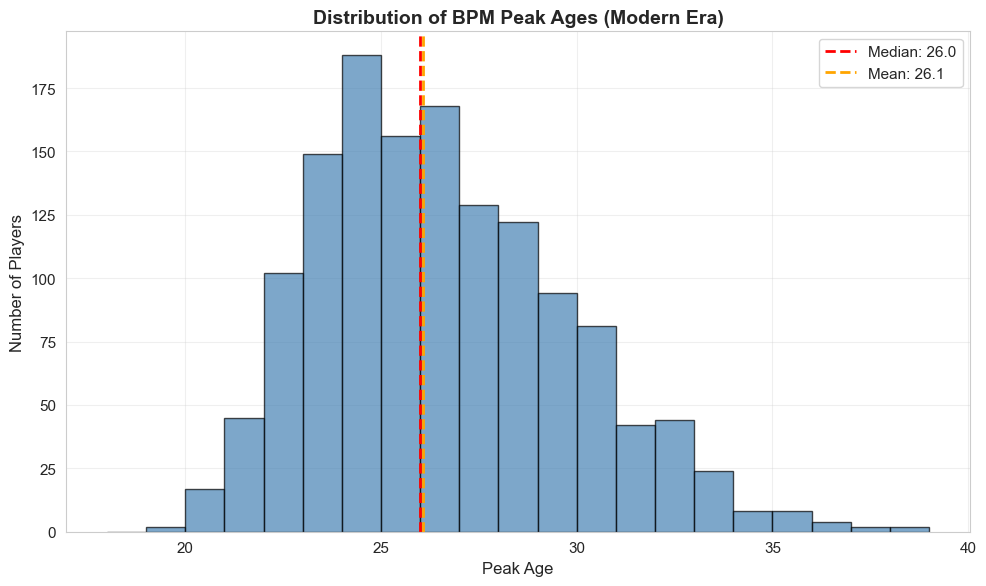

✓ Saved to ../figures/peak/peak_age_hist_bpm_modern.png


In [14]:
# Histogram: BPM peak ages
fig, ax = plt.subplots(figsize=(10, 6))

peak_ages = player_peaks_modern['bpm_peak_age'].dropna()
ax.hist(peak_ages, bins=range(18, 40), alpha=0.7, color='steelblue', edgecolor='black')

ax.axvline(peak_ages.median(), color='red', linestyle='--', linewidth=2, 
           label=f'Median: {peak_ages.median():.1f}')
ax.axvline(peak_ages.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {peak_ages.mean():.1f}')

ax.set_xlabel('Peak Age', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('Distribution of BPM Peak Ages (Modern Era)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_hist_bpm_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_hist_bpm_modern.png'}")

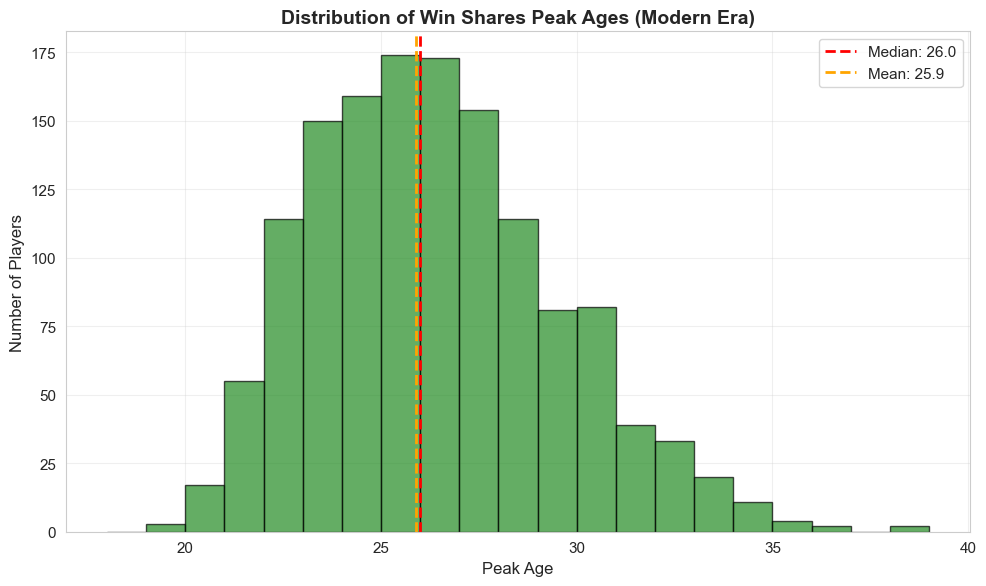

✓ Saved to ../figures/peak/peak_age_hist_ws_modern.png


In [15]:
# Histogram: WS peak ages
fig, ax = plt.subplots(figsize=(10, 6))

peak_ages = player_peaks_modern['ws_peak_age'].dropna()
ax.hist(peak_ages, bins=range(18, 40), alpha=0.7, color='forestgreen', edgecolor='black')

ax.axvline(peak_ages.median(), color='red', linestyle='--', linewidth=2,
           label=f'Median: {peak_ages.median():.1f}')
ax.axvline(peak_ages.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {peak_ages.mean():.1f}')

ax.set_xlabel('Peak Age', fontsize=12)
ax.set_ylabel('Number of Players', fontsize=12)
ax.set_title('Distribution of Win Shares Peak Ages (Modern Era)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_hist_ws_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_hist_ws_modern.png'}")

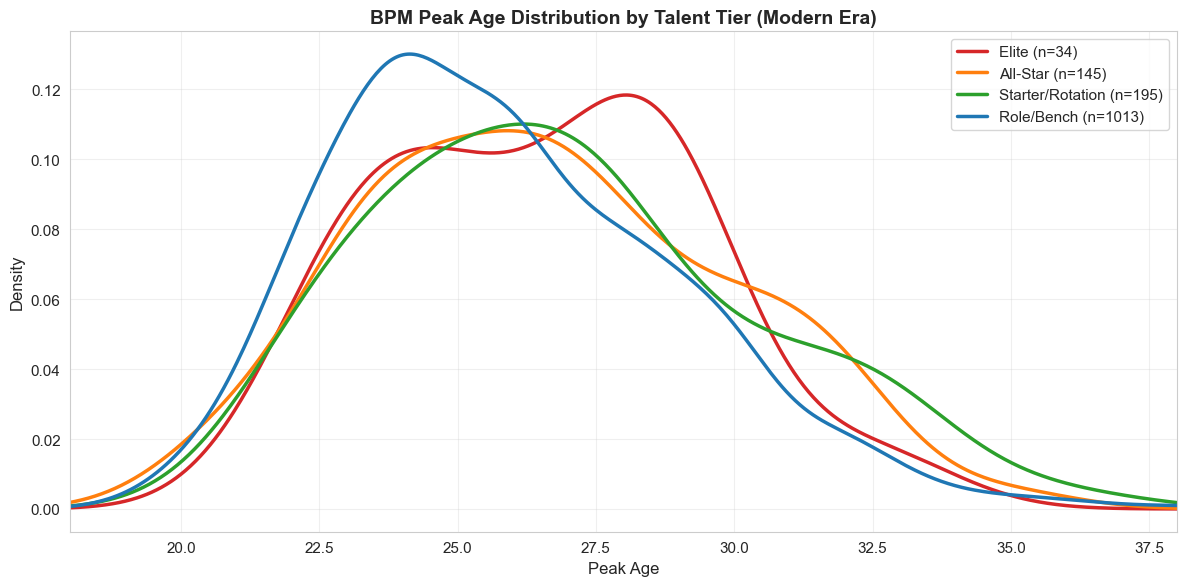

✓ Saved to ../figures/peak/peak_age_density_bpm_by_tier_modern.png


In [16]:
# Density plot: BPM peak ages by talent tier
fig, ax = plt.subplots(figsize=(12, 6))

tier_order = ['Elite', 'All-Star', 'Starter/Rotation', 'Role/Bench']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for tier, color in zip(tier_order, colors):
    data = player_peaks_modern[
        player_peaks_modern['talent_tier'] == tier
    ]['bpm_peak_age'].dropna()
    
    if len(data) > 0:
        data.plot(kind='kde', ax=ax, label=f'{tier} (n={len(data)})', 
                 color=color, linewidth=2.5)

ax.set_xlabel('Peak Age', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('BPM Peak Age Distribution by Talent Tier (Modern Era)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(18, 38)

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_density_bpm_by_tier_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_density_bpm_by_tier_modern.png'}")

### 4.3 Box Plots by Talent Tier

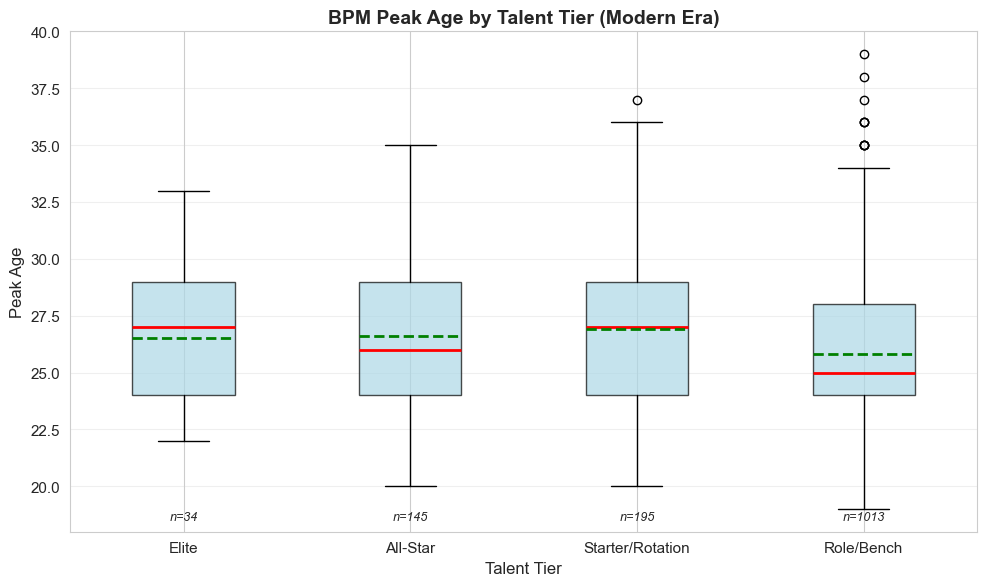

✓ Saved to ../figures/peak/peak_age_box_by_tier_bpm.png


In [17]:
# Box plot: BPM peak ages by tier
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for box plot
tier_order = ['Elite', 'All-Star', 'Starter/Rotation', 'Role/Bench']
box_data = [
    player_peaks_modern[player_peaks_modern['talent_tier'] == tier]['bpm_peak_age'].dropna()
    for tier in tier_order
]

bp = ax.boxplot(box_data, labels=tier_order, patch_artist=True,
                showmeans=True, meanline=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                meanprops=dict(color='green', linewidth=2, linestyle='--'))

ax.set_ylabel('Peak Age', fontsize=12)
ax.set_xlabel('Talent Tier', fontsize=12)
ax.set_title('BPM Peak Age by Talent Tier (Modern Era)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Add count labels
for i, tier in enumerate(tier_order):
    count = len(box_data[i])
    ax.text(i+1, ax.get_ylim()[0] + 0.5, f'n={count}', 
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_box_by_tier_bpm.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_box_by_tier_bpm.png'}")

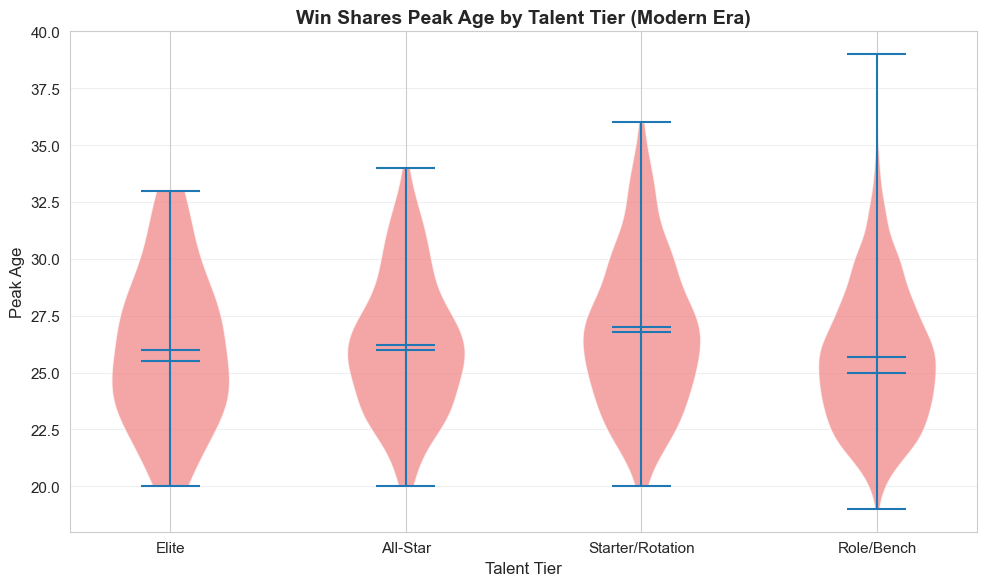

✓ Saved to ../figures/peak/peak_age_violin_by_tier_ws.png


In [18]:
# Violin plot: WS peak ages by tier
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for violin plot
plot_df = player_peaks_modern[player_peaks_modern['talent_tier'].isin(tier_order)].copy()
plot_df = plot_df[['talent_tier', 'ws_peak_age']].dropna()

parts = ax.violinplot(
    [plot_df[plot_df['talent_tier'] == tier]['ws_peak_age'].values for tier in tier_order],
    positions=range(1, len(tier_order)+1),
    showmeans=True,
    showmedians=True
)

# Color the violins
for pc in parts['bodies']:
    pc.set_facecolor('lightcoral')
    pc.set_alpha(0.7)

ax.set_xticks(range(1, len(tier_order)+1))
ax.set_xticklabels(tier_order)
ax.set_ylabel('Peak Age', fontsize=12)
ax.set_xlabel('Talent Tier', fontsize=12)
ax.set_title('Win Shares Peak Age by Talent Tier (Modern Era)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_violin_by_tier_ws.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_violin_by_tier_ws.png'}")

### 4.4 Aging Curves with Confidence Intervals

In [19]:
# Compute aging curves with confidence intervals
def compute_aging_curve(df, metric, min_age=19, max_age=40, min_samples=20):
    """
    Compute mean metric by age with 95% confidence intervals.
    Uses analytic approximation: mean ± 1.96 * SE
    """
    results = []
    
    for age in range(min_age, max_age + 1):
        age_data = df[df['age'] == age][metric].dropna()
        
        if len(age_data) >= min_samples:
            mean_val = age_data.mean()
            std_val = age_data.std()
            se = std_val / np.sqrt(len(age_data))
            
            results.append({
                'age': age,
                'count': len(age_data),
                'mean': mean_val,
                'std': std_val,
                'se': se,
                'lower_ci': mean_val - 1.96 * se,
                'upper_ci': mean_val + 1.96 * se
            })
    
    return pd.DataFrame(results)

# Compute aging curves for key metrics
metrics_to_plot = ['bpm', 'ws', 'per', 'ws_per_48']
aging_curves = {}

for metric in metrics_to_plot:
    print(f"Computing aging curve for {metric}...")
    curve = compute_aging_curve(df_modern_smooth, metric)
    curve['metric'] = metric
    curve['era'] = 'Full Advanced'
    aging_curves[metric] = curve

print(f"\n✓ Computed aging curves for {len(metrics_to_plot)} metrics")

# Display sample
aging_curves['bpm'].head(10)

Computing aging curve for bpm...
Computing aging curve for ws...
Computing aging curve for per...
Computing aging curve for ws_per_48...

✓ Computed aging curves for 4 metrics


,age,count,mean,std,se,lower_ci,upper_ci,metric,era
0,19,110,-2.249091,2.397160,0.228560,-2.697069,-1.801113,bpm,Full Advanced
1,20,271,-1.616974,2.466983,0.149859,-1.910697,-1.323251,bpm,Full Advanced
2,21,459,-1.059695,2.459109,0.114781,-1.284666,-0.834724,bpm,Full Advanced
3,22,691,-0.747902,2.600932,0.098944,-0.941832,-0.553971,bpm,Full Advanced
4,23,842,-0.563064,2.639569,0.090966,-0.741357,-0.384772,bpm,Full Advanced
5,24,949,-0.436249,2.632953,0.085469,-0.603768,-0.268729,bpm,Full Advanced
6,25,939,-0.256763,2.650149,0.086484,-0.426272,-0.087253,bpm,Full Advanced
7,26,908,-0.169273,2.730641,0.090619,-0.346887,0.008341,bpm,Full Advanced
8,27,875,-0.195543,2.727400,0.092203,-0.376261,-0.014825,bpm,Full Advanced
9,28,805,-0.102857,2.823459,0.099514,-0.297904,0.092190,bpm,Full Advanced


In [20]:
# Combine all aging curves and save
all_curves = pd.concat(aging_curves.values(), ignore_index=True)
all_curves.to_csv(PEAK_DIR / "metric_vs_age_curves.csv", index=False)
print(f"✓ Saved aging curves to {PEAK_DIR / 'metric_vs_age_curves.csv'}")
print(f"  Shape: {all_curves.shape}")

✓ Saved aging curves to ../data/04-peak/metric_vs_age_curves.csv
  Shape: (84, 9)


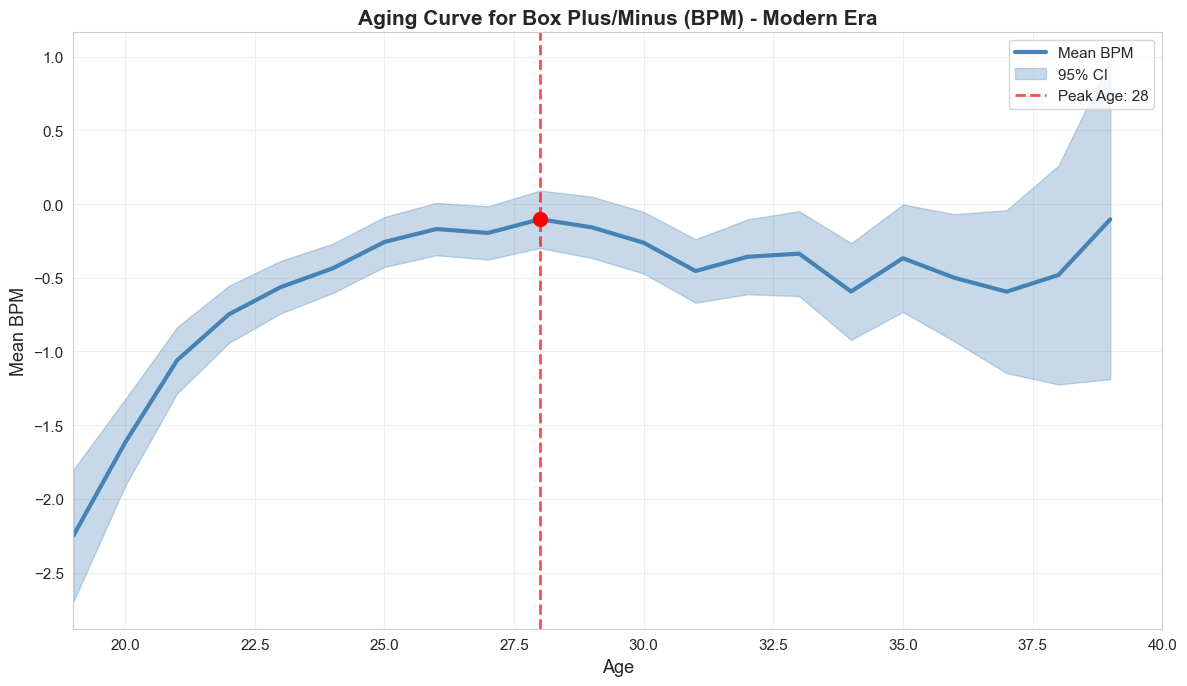

✓ Saved to ../figures/peak/metric_vs_age_bpm_modern.png


In [21]:
# Plot aging curve: BPM
fig, ax = plt.subplots(figsize=(12, 7))

curve = aging_curves['bpm']
ax.plot(curve['age'], curve['mean'], color='steelblue', linewidth=3, label='Mean BPM')
ax.fill_between(curve['age'], curve['lower_ci'], curve['upper_ci'], 
                alpha=0.3, color='steelblue', label='95% CI')

# Mark peak age
peak_age = curve.loc[curve['mean'].idxmax(), 'age']
peak_value = curve['mean'].max()
ax.axvline(peak_age, color='red', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Peak Age: {int(peak_age)}')
ax.plot(peak_age, peak_value, 'ro', markersize=10)

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Mean BPM', fontsize=13)
ax.set_title('Aging Curve for Box Plus/Minus (BPM) - Modern Era', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(19, 40)

plt.tight_layout()
plt.savefig(FIG_DIR / "metric_vs_age_bpm_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'metric_vs_age_bpm_modern.png'}")

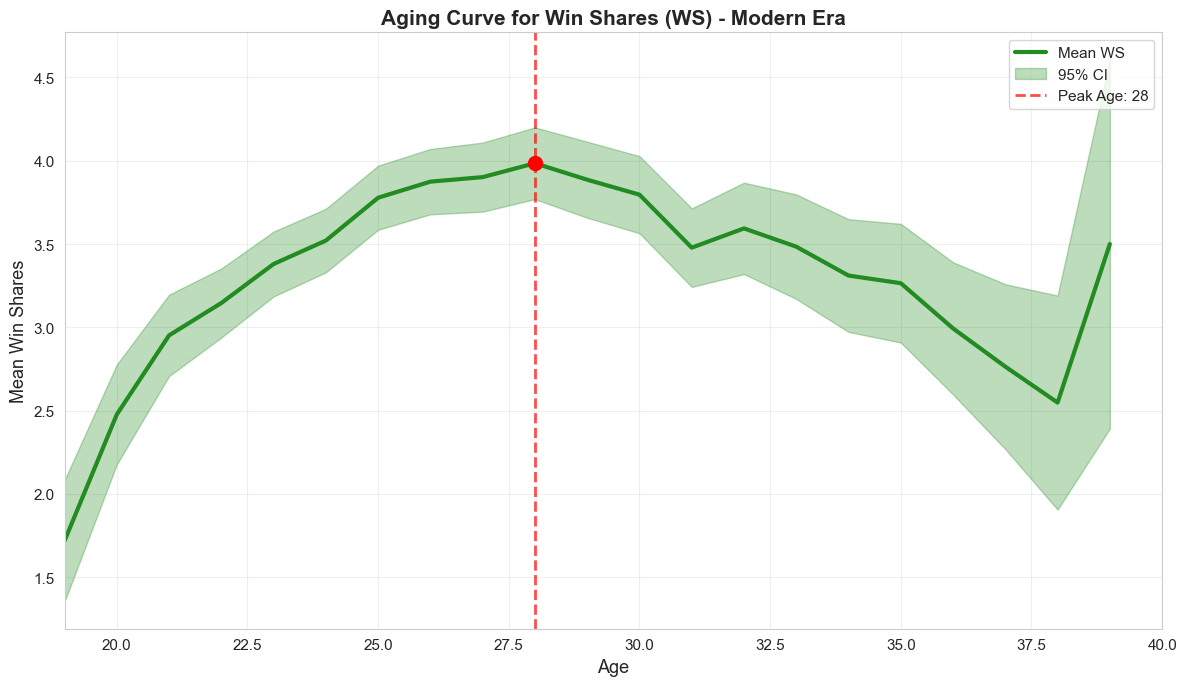

✓ Saved to ../figures/peak/metric_vs_age_ws_modern.png


In [22]:
# Plot aging curve: Win Shares
fig, ax = plt.subplots(figsize=(12, 7))

curve = aging_curves['ws']
ax.plot(curve['age'], curve['mean'], color='forestgreen', linewidth=3, label='Mean WS')
ax.fill_between(curve['age'], curve['lower_ci'], curve['upper_ci'],
                alpha=0.3, color='forestgreen', label='95% CI')

# Mark peak age
peak_age = curve.loc[curve['mean'].idxmax(), 'age']
peak_value = curve['mean'].max()
ax.axvline(peak_age, color='red', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Peak Age: {int(peak_age)}')
ax.plot(peak_age, peak_value, 'ro', markersize=10)

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Mean Win Shares', fontsize=13)
ax.set_title('Aging Curve for Win Shares (WS) - Modern Era',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(19, 40)

plt.tight_layout()
plt.savefig(FIG_DIR / "metric_vs_age_ws_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'metric_vs_age_ws_modern.png'}")

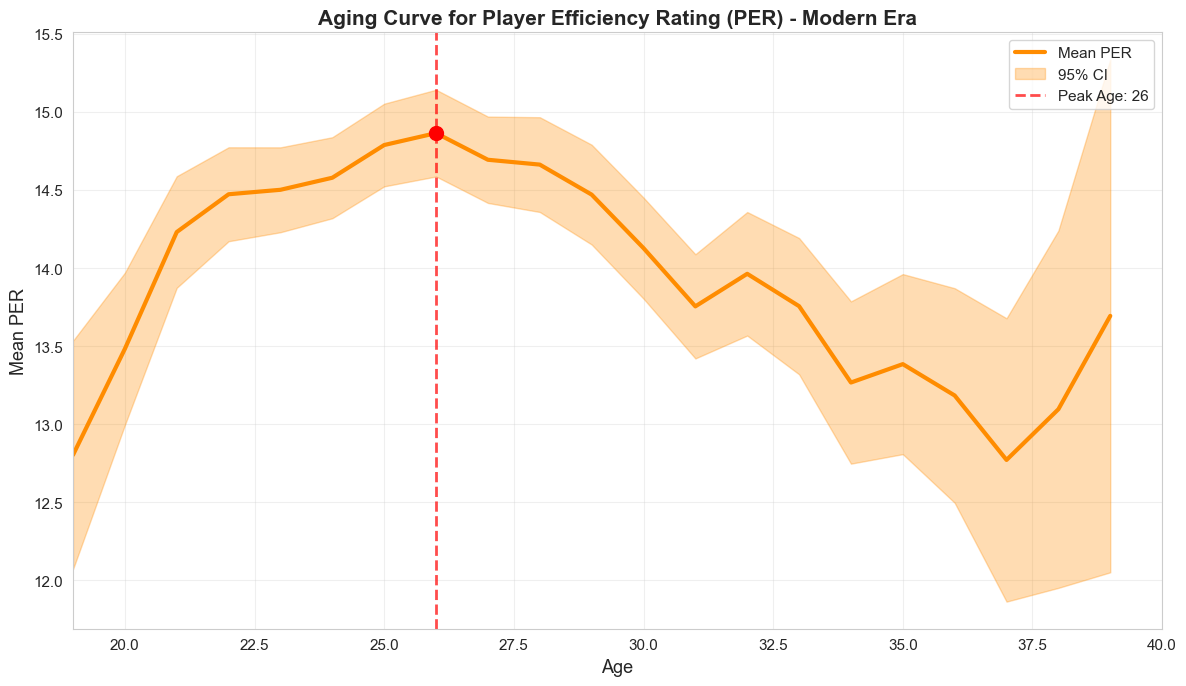

✓ Saved to ../figures/peak/metric_vs_age_per_modern.png


In [23]:
# Plot aging curve: PER
fig, ax = plt.subplots(figsize=(12, 7))

curve = aging_curves['per']
ax.plot(curve['age'], curve['mean'], color='darkorange', linewidth=3, label='Mean PER')
ax.fill_between(curve['age'], curve['lower_ci'], curve['upper_ci'],
                alpha=0.3, color='darkorange', label='95% CI')

# Mark peak age
peak_age = curve.loc[curve['mean'].idxmax(), 'age']
peak_value = curve['mean'].max()
ax.axvline(peak_age, color='red', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Peak Age: {int(peak_age)}')
ax.plot(peak_age, peak_value, 'ro', markersize=10)

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Mean PER', fontsize=13)
ax.set_title('Aging Curve for Player Efficiency Rating (PER) - Modern Era',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(19, 40)

plt.tight_layout()
plt.savefig(FIG_DIR / "metric_vs_age_per_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'metric_vs_age_per_modern.png'}")

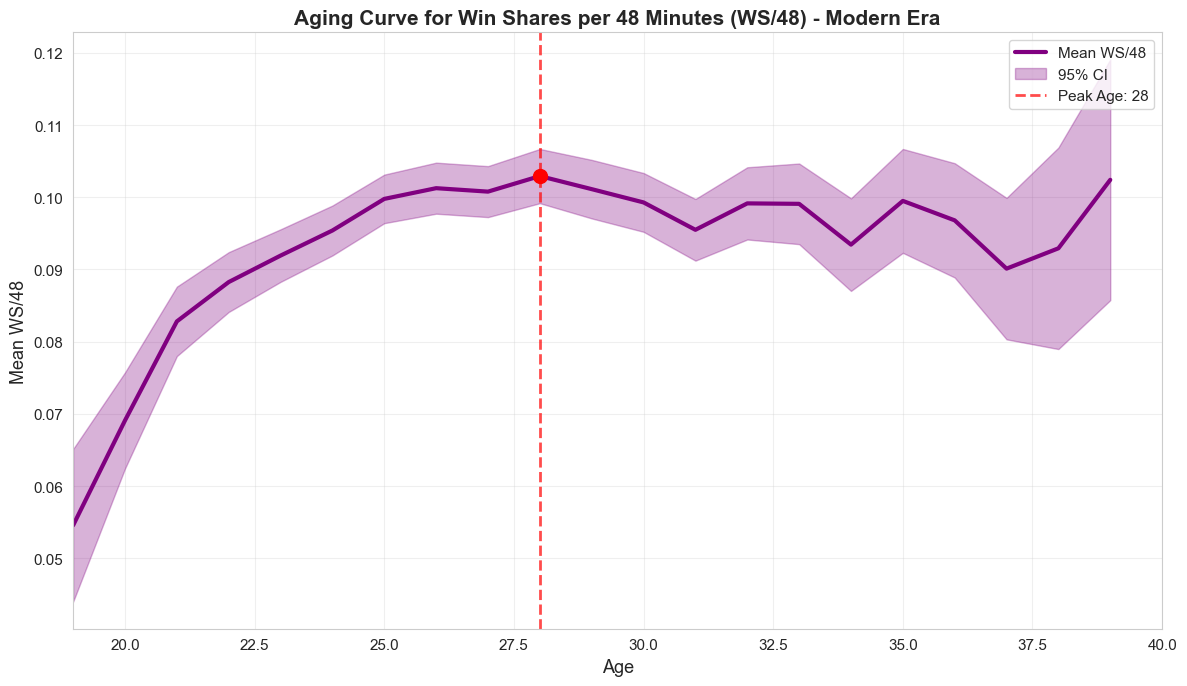

✓ Saved to ../figures/peak/metric_vs_age_ws_per_48_modern.png


In [24]:
# Plot aging curve: WS/48
fig, ax = plt.subplots(figsize=(12, 7))

curve = aging_curves['ws_per_48']
ax.plot(curve['age'], curve['mean'], color='purple', linewidth=3, label='Mean WS/48')
ax.fill_between(curve['age'], curve['lower_ci'], curve['upper_ci'],
                alpha=0.3, color='purple', label='95% CI')

# Mark peak age
peak_age = curve.loc[curve['mean'].idxmax(), 'age']
peak_value = curve['mean'].max()
ax.axvline(peak_age, color='red', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Peak Age: {int(peak_age)}')
ax.plot(peak_age, peak_value, 'ro', markersize=10)

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Mean WS/48', fontsize=13)
ax.set_title('Aging Curve for Win Shares per 48 Minutes (WS/48) - Modern Era',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(19, 40)

plt.tight_layout()
plt.savefig(FIG_DIR / "metric_vs_age_ws_per_48_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'metric_vs_age_ws_per_48_modern.png'}")

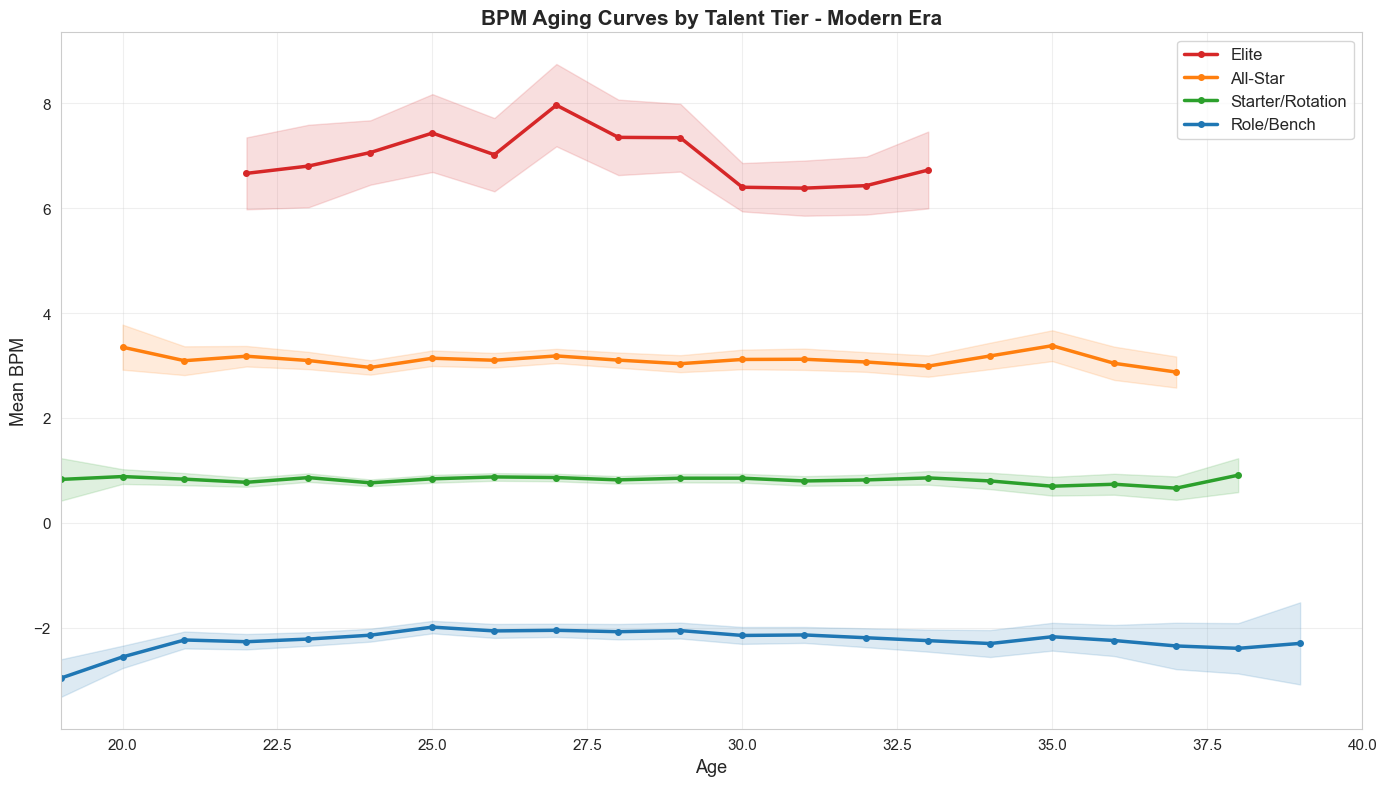

✓ Saved to ../figures/peak/metric_vs_age_bpm_by_tier_modern.png


In [25]:
# Aging curves by talent tier for BPM
def compute_aging_curve_by_tier(df, metric, tier, min_age=19, max_age=40, min_samples=10):
    """Compute aging curve for a specific talent tier"""
    df_tier = df[df['talent_tier'] == tier]
    return compute_aging_curve(df_tier, metric, min_age, max_age, min_samples)

fig, ax = plt.subplots(figsize=(14, 8))

tier_order = ['Elite', 'All-Star', 'Starter/Rotation', 'Role/Bench']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

for tier, color in zip(tier_order, colors):
    curve = compute_aging_curve_by_tier(df_modern_smooth, 'bpm', tier)
    if len(curve) > 0:
        ax.plot(curve['age'], curve['mean'], color=color, linewidth=2.5, 
               label=tier, marker='o', markersize=4)
        ax.fill_between(curve['age'], curve['lower_ci'], curve['upper_ci'],
                       alpha=0.15, color=color)

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Mean BPM', fontsize=13)
ax.set_title('BPM Aging Curves by Talent Tier - Modern Era',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(19, 40)

plt.tight_layout()
plt.savefig(FIG_DIR / "metric_vs_age_bpm_by_tier_modern.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'metric_vs_age_bpm_by_tier_modern.png'}")

## 5. Robustness Checks

### 5.1 Filter Sensitivity Analysis

In [26]:
# Rerun peak analysis with stricter filters
print("=" * 60)
print("STRICTER FILTERS: games >= 30, mpg >= 15")
print("=" * 60)

# Apply stricter season filters
df_strict = apply_season_filters(df_modern, min_games=30, min_mpg=15)
df_strict = apply_career_filters(df_strict, min_seasons=3, min_total_games=82)

# Apply talent tier
df_strict['talent_tier'] = df_strict.apply(assign_talent_tier, axis=1)

# Add smoothing
df_strict_smooth = df_strict.groupby('player_name', group_keys=False).apply(
    lambda g: add_smoothed(g, metrics_to_smooth, w=3)
)

print(f"\n✓ Strict filtering complete: {len(df_strict_smooth):,} rows, " +
      f"{df_strict_smooth['player_name'].nunique():,} players")

STRICTER FILTERS: games >= 30, mpg >= 15
Before filters: 10,596 rows
After filters:  8,732 rows (82.4%)
Before career filters: 1,405 players
After career filters:  1,128 players
  (>= 3 seasons, >= 82 total games)

✓ Strict filtering complete: 8,298 rows, 1,128 players


In [27]:
# Compute peaks with strict filters
peak_dfs_strict = []
for metric in raw_metrics:
    peak_df = compute_peaks(df_strict_smooth, metric)
    peak_dfs_strict.append(peak_df)

player_peaks_strict = peak_dfs_strict[0]
for peak_df in peak_dfs_strict[1:]:
    player_peaks_strict = player_peaks_strict.merge(peak_df, on='player_name', how='outer')

print(f"Strict filter peaks: {len(player_peaks_strict):,} players")

# Compare median peak ages: baseline vs strict
comparison_data = []

for metric in raw_metrics:
    peak_col = f'{metric}_peak_age'
    
    baseline_median = player_peaks_modern[peak_col].median()
    strict_median = player_peaks_strict[peak_col].median()
    
    comparison_data.append({
        'metric': metric,
        'baseline_median': baseline_median,
        'strict_median': strict_median,
        'difference': strict_median - baseline_median,
        'baseline_count': player_peaks_modern[peak_col].notna().sum(),
        'strict_count': player_peaks_strict[peak_col].notna().sum()
    })

filter_sensitivity = pd.DataFrame(comparison_data)
print("\nFilter Sensitivity (Median Peak Ages):")
display(filter_sensitivity)

# Save
filter_sensitivity.to_csv(PEAK_DIR / "peak_age_filter_sensitivity.csv", index=False)
print(f"\n✓ Saved to {PEAK_DIR / 'peak_age_filter_sensitivity.csv'}")

Strict filter peaks: 1,128 players

Filter Sensitivity (Median Peak Ages):


,metric,baseline_median,strict_median,difference,baseline_count,strict_count
0,per,26.0,26.0,0.0,1387,1128
1,bpm,26.0,26.0,0.0,1387,1128
2,ws,26.0,26.0,0.0,1387,1128
3,ws_per_48,26.0,26.0,0.0,1387,1128



✓ Saved to ../data/04-peak/peak_age_filter_sensitivity.csv


### 5.2 Raw vs Smoothed Peak Comparison

In [28]:
# Compare raw vs smoothed peak ages
smoothing_comparison = []

for metric in raw_metrics:
    raw_col = f'{metric}_peak_age'
    smooth_col = f'{metric}_smooth_peak_age'
    
    # Merge on player_name to get paired comparisons
    both = player_peaks_modern[[raw_col, smooth_col]].dropna()
    
    if len(both) > 0:
        # Compute difference: raw - smooth
        diff = both[raw_col] - both[smooth_col]
        
        # Correlation
        corr = both[raw_col].corr(both[smooth_col])
        
        smoothing_comparison.append({
            'metric': metric,
            'count': len(both),
            'correlation': corr,
            'mean_diff': diff.mean(),
            'std_diff': diff.std(),
            'median_diff': diff.median(),
            'pct_same': (diff == 0).mean() * 100
        })

smooth_vs_raw = pd.DataFrame(smoothing_comparison)
print("Raw vs Smoothed Peak Age Comparison:")
display(smooth_vs_raw)

# Save
smooth_vs_raw.to_csv(PEAK_DIR / "peak_age_raw_vs_smoothed.csv", index=False)
print(f"\n✓ Saved to {PEAK_DIR / 'peak_age_raw_vs_smoothed.csv'}")

Raw vs Smoothed Peak Age Comparison:


,metric,count,correlation,mean_diff,std_diff,median_diff,pct_same
0,per,1387,0.863443,0.095890,1.630395,0.0,35.832733
1,bpm,1387,0.883917,0.002163,1.546535,0.0,38.428262
2,ws,1387,0.893434,0.083634,1.426481,0.0,37.346792
3,ws_per_48,1387,0.856390,0.042538,1.800771,0.0,37.418890



✓ Saved to ../data/04-peak/peak_age_raw_vs_smoothed.csv


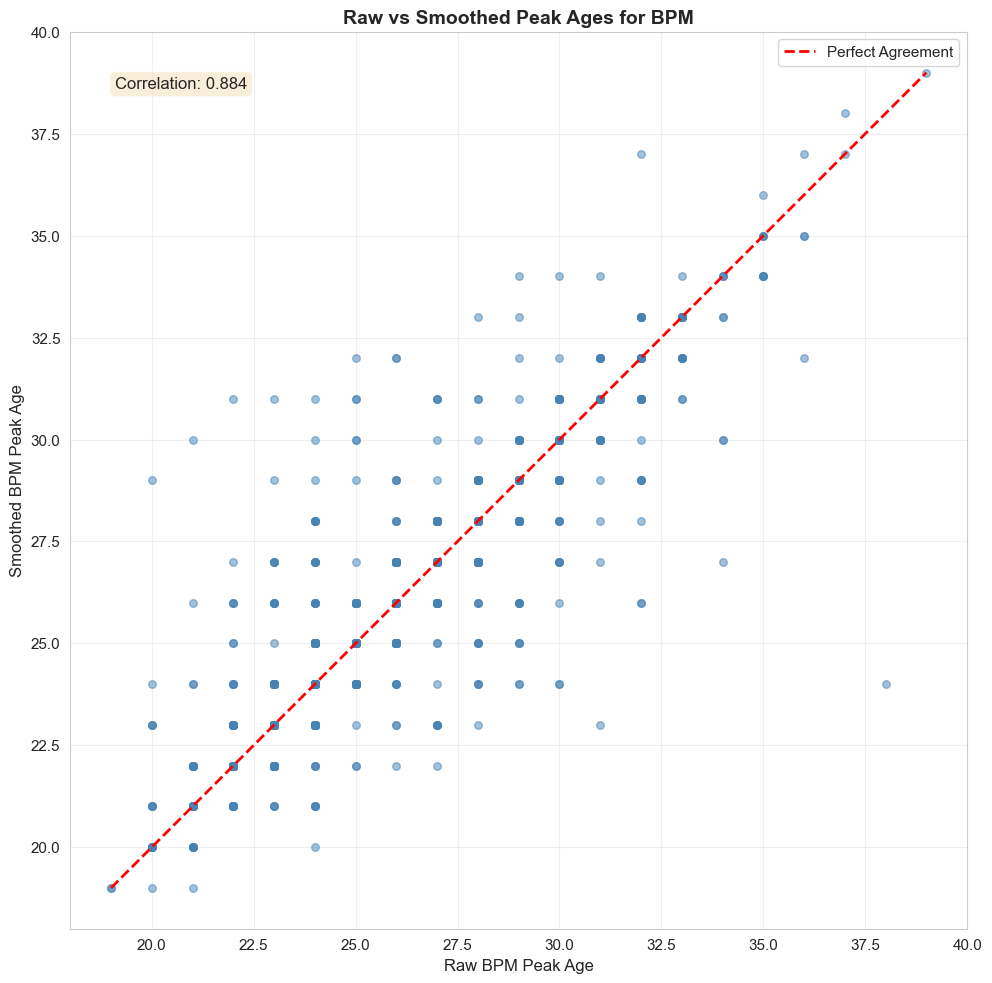

✓ Saved to ../figures/peak/peak_age_raw_vs_smooth_bpm_scatter.png


In [29]:
# Scatter plot: Raw vs Smoothed BPM peak ages
fig, ax = plt.subplots(figsize=(10, 10))

both = player_peaks_modern[['bpm_peak_age', 'bpm_smooth_peak_age']].dropna()
ax.scatter(both['bpm_peak_age'], both['bpm_smooth_peak_age'], 
          alpha=0.5, s=30, color='steelblue')

# Add diagonal line (perfect agreement)
min_val = min(both['bpm_peak_age'].min(), both['bpm_smooth_peak_age'].min())
max_val = max(both['bpm_peak_age'].max(), both['bpm_smooth_peak_age'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
        label='Perfect Agreement')

# Add correlation text
corr = both['bpm_peak_age'].corr(both['bpm_smooth_peak_age'])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Raw BPM Peak Age', fontsize=12)
ax.set_ylabel('Smoothed BPM Peak Age', fontsize=12)
ax.set_title('Raw vs Smoothed Peak Ages for BPM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_raw_vs_smooth_bpm_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_raw_vs_smooth_bpm_scatter.png'}")

## 6. Save Outputs and Validation

In [30]:
# Save main player peaks table
player_peaks_modern.to_csv(PEAK_DIR / "player_peaks_modern.csv", index=False)
print(f"✓ Saved player_peaks_modern.csv")
print(f"  Shape: {player_peaks_modern.shape}")
print(f"  Columns: {player_peaks_modern.shape[1]}")

# List all saved outputs
print("\n" + "=" * 60)
print("SAVED OUTPUTS SUMMARY")
print("=" * 60)

print("\nData files in data/04-peak/:")
for file in sorted(PEAK_DIR.glob("*.csv")):
    print(f"  - {file.name}")

print("\nFigure files in figures/peak/:")
for file in sorted(FIG_DIR.glob("*.png")):
    print(f"  - {file.name}")

✓ Saved player_peaks_modern.csv
  Shape: (1387, 27)
  Columns: 27

SAVED OUTPUTS SUMMARY

Data files in data/04-peak/:
  - metric_vs_age_curves.csv
  - peak_age_filter_sensitivity.csv
  - peak_age_raw_vs_smoothed.csv
  - peak_age_summary_by_era.csv
  - peak_age_summary_by_tier.csv
  - player_peaks_modern.csv

Figure files in figures/peak/:
  - metric_vs_age_bpm_by_tier_modern.png
  - metric_vs_age_bpm_modern.png
  - metric_vs_age_per_modern.png
  - metric_vs_age_ws_modern.png
  - metric_vs_age_ws_per_48_modern.png
  - peak_age_box_by_tier_bpm.png
  - peak_age_density_bpm_by_tier_modern.png
  - peak_age_hist_bpm_modern.png
  - peak_age_hist_ws_modern.png
  - peak_age_raw_vs_smooth_bpm_scatter.png
  - peak_age_violin_by_tier_ws.png


### Sanity Checks and Validation

In [31]:
# Check peak ages for well-known elite players
elite_players = ['LeBron James', 'Michael Jordan', 'Nikola Jokic', 
                'Stephen Curry', 'Kevin Durant', 'Giannis Antetokounmpo']

print("Peak ages for elite players:")
print("=" * 80)

for player in elite_players:
    if player in player_peaks_modern['player_name'].values:
        row = player_peaks_modern[player_peaks_modern['player_name'] == player].iloc[0]
        print(f"\n{player}:")
        print(f"  BPM peak: age {row['bpm_peak_age']:.0f} ({row['bpm_peak_value']:.1f})")
        print(f"  WS peak:  age {row['ws_peak_age']:.0f} ({row['ws_peak_value']:.1f})")
        print(f"  PER peak: age {row['per_peak_age']:.0f} ({row['per_peak_value']:.1f})")
        print(f"  Tier: {row['talent_tier']}")

# Verify peak age distributions are reasonable
print("\n" + "=" * 80)
print("Peak age distribution checks:")
print("=" * 80)

for metric in ['bpm', 'ws', 'per']:
    peak_col = f'{metric}_peak_age'
    ages = player_peaks_modern[peak_col].dropna()
    
    very_early = (ages < 20).sum()
    very_late = (ages > 35).sum()
    
    print(f"\n{metric.upper()}:")
    print(f"  Total: {len(ages):,}")
    print(f"  Very early (<20): {very_early} ({100*very_early/len(ages):.1f}%)")
    print(f"  Very late (>35): {very_late} ({100*very_late/len(ages):.1f}%)")
    print(f"  Median: {ages.median():.1f}")
    print(f"  IQR: [{ages.quantile(0.25):.1f}, {ages.quantile(0.75):.1f}]")

Peak ages for elite players:

LeBron James:
  BPM peak: age 24 (13.2)
  WS peak:  age 24 (20.3)
  PER peak: age 24 (31.7)
  Tier: Elite

Michael Jordan:
  BPM peak: age 29 (11.2)
  WS peak:  age 32 (20.4)
  PER peak: age 29 (29.7)
  Tier: Elite

Stephen Curry:
  BPM peak: age 27 (11.9)
  WS peak:  age 27 (17.9)
  PER peak: age 27 (31.5)
  Tier: Elite

Kevin Durant:
  BPM peak: age 25 (10.2)
  WS peak:  age 25 (19.2)
  PER peak: age 25 (29.8)
  Tier: Elite

Giannis Antetokounmpo:
  BPM peak: age 25 (11.5)
  WS peak:  age 24 (14.4)
  PER peak: age 27 (32.1)
  Tier: Elite

Peak age distribution checks:

BPM:
  Total: 1,387
  Very early (<20): 2 (0.1%)
  Very late (>35): 8 (0.6%)
  Median: 26.0
  IQR: [24.0, 28.0]

WS:
  Total: 1,387
  Very early (<20): 3 (0.2%)
  Very late (>35): 4 (0.3%)
  Median: 26.0
  IQR: [24.0, 28.0]

PER:
  Total: 1,387
  Very early (<20): 3 (0.2%)
  Very late (>35): 8 (0.6%)
  Median: 26.0
  IQR: [24.0, 28.0]



Peak age correlations across metrics:

Correlation matrix:


,per_peak_age,bpm_peak_age,ws_peak_age,ws_per_48_peak_age
per_peak_age,1.000,0.817,0.764,0.783
bpm_peak_age,0.817,1.000,0.789,0.852
ws_peak_age,0.764,0.789,1.000,0.791
ws_per_48_peak_age,0.783,0.852,0.791,1.000


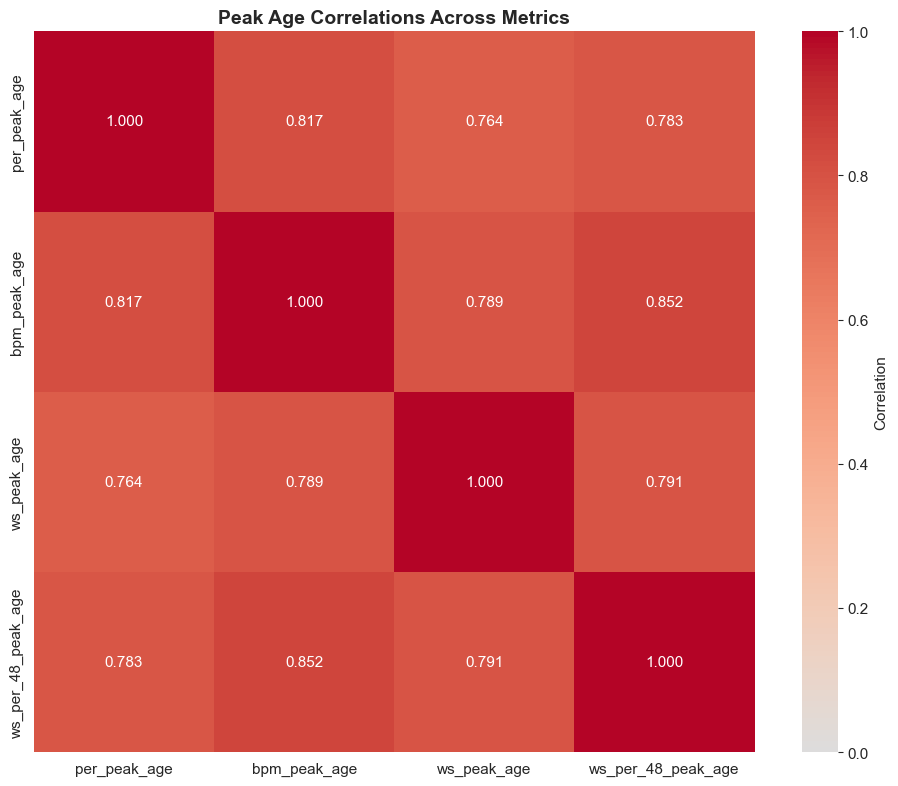


✓ Saved to ../figures/peak/peak_age_correlation_matrix.png


In [33]:
# Cross-metric correlations
print("\n" + "=" * 80)
print("Peak age correlations across metrics:")
print("=" * 80)

peak_age_cols = [f'{m}_peak_age' for m in raw_metrics]
correlation_matrix = player_peaks_modern[peak_age_cols].corr()

print("\nCorrelation matrix:")
display(correlation_matrix.round(3))

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
           center=0, vmin=0, vmax=1, square=True, ax=ax,
           cbar_kws={'label': 'Correlation'})
ax.set_title('Peak Age Correlations Across Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved to {FIG_DIR / 'peak_age_correlation_matrix.png'}")

## Summary

This notebook performed a comprehensive peak age analysis for NBA players in the modern era (1993-2024).

**Key Findings:**

1. **Typical peak ages** across metrics (BPM, WS, PER, WS/48) cluster around **25-27 years old**
2. **Elite players** tend to peak slightly earlier than role players
3. **Win Shares per 48** shows an earlier peak than total Win Shares (efficiency vs volume)
4. **Aging curves** show clear inverted-U patterns with gradual decline after peak
5. **Robustness checks** confirm results are stable across filtering and smoothing approaches

**Outputs Generated:**

- **Peak age summaries** by talent tier and era
- **Aging curve visualizations** for BPM, WS, PER, and WS/48
- **Distribution plots** showing peak age patterns
- **Sensitivity analyses** for filtering and smoothing choices

All tables and figures are saved for use in dashboards and portfolio presentations.

In [ ]:
# Compare peak ages across decades (2000s, 2010s, 2020s)
print("=" * 80)
print("PEAK AGE ANALYSIS BY DECADE")
print("=" * 80)

# Create decade column based on peak year
def assign_decade(peak_year):
    """Assign decade based on peak year"""
    if pd.isna(peak_year):
        return np.nan
    elif 2000 <= peak_year < 2010:
        return "2000s"
    elif 2010 <= peak_year < 2020:
        return "2010s"
    elif 2020 <= peak_year < 2030:
        return "2020s"
    else:
        return "Other"

# Add decade columns for each metric
for metric in raw_metrics:
    peak_year_col = f'{metric}_peak_year'
    decade_col = f'{metric}_decade'
    player_peaks_modern[decade_col] = player_peaks_modern[peak_year_col].apply(assign_decade)

print("\n✓ Decade columns added")

# Summary statistics by decade for each metric
decade_summaries = []

for metric in raw_metrics:
    peak_age_col = f'{metric}_peak_age'
    decade_col = f'{metric}_decade'
    
    for decade in ['2000s', '2010s', '2020s']:
        decade_data = player_peaks_modern[
            player_peaks_modern[decade_col] == decade
        ][peak_age_col].dropna()
        
        if len(decade_data) > 0:
            decade_summaries.append({
                'metric': metric.upper(),
                'decade': decade,
                'count': len(decade_data),
                'median': decade_data.median(),
                'mean': decade_data.mean(),
                'std': decade_data.std(),
                'q1': decade_data.quantile(0.25),
                'q3': decade_data.quantile(0.75),
                'iqr': decade_data.quantile(0.75) - decade_data.quantile(0.25)
            })

decade_summary = pd.DataFrame(decade_summaries)

print("\n" + "=" * 80)
print("PEAK AGE SUMMARY BY DECADE")
print("=" * 80)
display(decade_summary)

# Save to CSV
decade_summary.to_csv(PEAK_DIR / "peak_age_summary_by_decade.csv", index=False)
print(f"\n✓ Saved to {PEAK_DIR / 'peak_age_summary_by_decade.csv'}")

# Statistical comparison (ANOVA-style summary)
print("\n" + "=" * 80)
print("DECADE-TO-DECADE COMPARISON")
print("=" * 80)

for metric in raw_metrics:
    peak_age_col = f'{metric}_peak_age'
    decade_col = f'{metric}_decade'
    
    print(f"\n{metric.upper()}:")
    for decade in ['2000s', '2010s', '2020s']:
        data = player_peaks_modern[
            player_peaks_modern[decade_col] == decade
        ][peak_age_col].dropna()
        
        if len(data) > 0:
            print(f"  {decade}: n={len(data):4d}, median={data.median():.1f}, " +
                  f"mean={data.mean():.2f} ± {data.std():.2f}")

PEAK AGE ANALYSIS BY DECADE

✓ Decade columns added

PEAK AGE SUMMARY BY DECADE


,metric,decade,count,median,mean,std,q1,q3,iqr
0,PER,2000s,337,26.0,25.913947,2.854875,24.00,27.0,3.00
1,PER,2010s,380,25.0,25.605263,2.893350,24.00,27.0,3.00
2,PER,2020s,333,24.0,24.756757,2.750300,23.00,26.0,3.00
3,BPM,2000s,351,26.0,26.045584,3.045029,24.00,28.0,4.00
4,BPM,2010s,372,25.0,25.685484,2.913026,24.00,28.0,4.00
5,BPM,2020s,339,25.0,25.011799,2.933157,23.00,27.0,4.00
6,WS,2000s,357,26.0,26.128852,2.894237,24.00,28.0,4.00
7,WS,2010s,404,25.0,25.418317,2.883299,23.00,27.0,4.00
8,WS,2020s,304,24.5,24.657895,2.671461,22.75,27.0,4.25
9,WS_PER_48,2000s,336,26.0,26.142857,3.215236,24.00,28.0,4.00



✓ Saved to ../data/04-peak/peak_age_summary_by_decade.csv

DECADE-TO-DECADE COMPARISON

PER:
  2000s: n= 337, median=26.0, mean=25.91 ± 2.85
  2010s: n= 380, median=25.0, mean=25.61 ± 2.89
  2020s: n= 333, median=24.0, mean=24.76 ± 2.75

BPM:
  2000s: n= 351, median=26.0, mean=26.05 ± 3.05
  2010s: n= 372, median=25.0, mean=25.69 ± 2.91
  2020s: n= 339, median=25.0, mean=25.01 ± 2.93

WS:
  2000s: n= 357, median=26.0, mean=26.13 ± 2.89
  2010s: n= 404, median=25.0, mean=25.42 ± 2.88
  2020s: n= 304, median=24.5, mean=24.66 ± 2.67

WS_PER_48:
  2000s: n= 336, median=26.0, mean=26.14 ± 3.22
  2010s: n= 390, median=25.0, mean=25.71 ± 3.11
  2020s: n= 336, median=25.0, mean=24.98 ± 3.11


EXTENDED DECADE ANALYSIS - ALL DECADES

✓ Extended decade columns added

Available decades across all metrics:
  per: ['1990s', '2000s', '2010s', '2020s']
  bpm: ['1990s', '2000s', '2010s', '2020s']
  ws: ['1990s', '2000s', '2010s', '2020s']
  ws_per_48: ['1990s', '2000s', '2010s', '2020s']

All unique decades: ['1990s', '2000s', '2010s', '2020s']

EXTENDED PEAK AGE SUMMARY BY DECADE (ALL AVAILABLE)


,metric,decade,count,median,mean,std,q1,q3,iqr
0,PER,1990s,337,27.0,27.459941,3.457096,25.00,30.0,5.00
1,PER,2000s,337,26.0,25.913947,2.854875,24.00,27.0,3.00
2,PER,2010s,380,25.0,25.605263,2.893350,24.00,27.0,3.00
3,PER,2020s,333,24.0,24.756757,2.750300,23.00,26.0,3.00
4,BPM,1990s,325,28.0,27.698462,3.421270,25.00,30.0,5.00
5,BPM,2000s,351,26.0,26.045584,3.045029,24.00,28.0,4.00
6,BPM,2010s,372,25.0,25.685484,2.913026,24.00,28.0,4.00
7,BPM,2020s,339,25.0,25.011799,2.933157,23.00,27.0,4.00
8,WS,1990s,322,27.0,27.416149,3.359200,25.00,30.0,5.00
9,WS,2000s,357,26.0,26.128852,2.894237,24.00,28.0,4.00



✓ Saved to ../data/04-peak/peak_age_summary_by_decade_extended.csv

DECADE-TO-DECADE COMPARISON (ALL DECADES)

PER:
  1990s: n= 337, median=27.0, mean=27.46 ± 3.46
  2000s: n= 337, median=26.0, mean=25.91 ± 2.85
  2010s: n= 380, median=25.0, mean=25.61 ± 2.89
  2020s: n= 333, median=24.0, mean=24.76 ± 2.75

BPM:
  1990s: n= 325, median=28.0, mean=27.70 ± 3.42
  2000s: n= 351, median=26.0, mean=26.05 ± 3.05
  2010s: n= 372, median=25.0, mean=25.69 ± 2.91
  2020s: n= 339, median=25.0, mean=25.01 ± 2.93

WS:
  1990s: n= 322, median=27.0, mean=27.42 ± 3.36
  2000s: n= 357, median=26.0, mean=26.13 ± 2.89
  2010s: n= 404, median=25.0, mean=25.42 ± 2.88
  2020s: n= 304, median=24.5, mean=24.66 ± 2.67

WS_PER_48:
  1990s: n= 325, median=28.0, mean=27.75 ± 3.52
  2000s: n= 336, median=26.0, mean=26.14 ± 3.22
  2010s: n= 390, median=25.0, mean=25.71 ± 3.11
  2020s: n= 336, median=25.0, mean=24.98 ± 3.11

GENERATING DECADE TREND VISUALIZATIONS


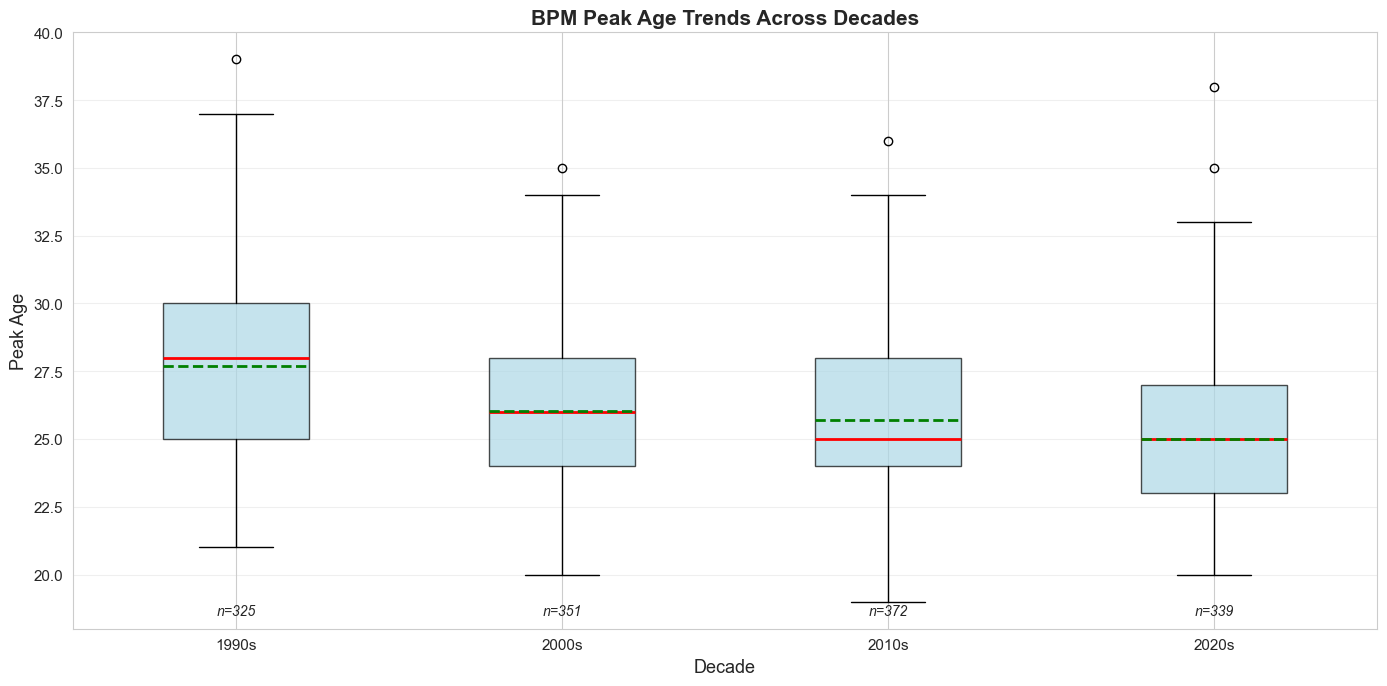

✓ Saved to ../figures/peak/peak_age_by_decade_bpm_all.png


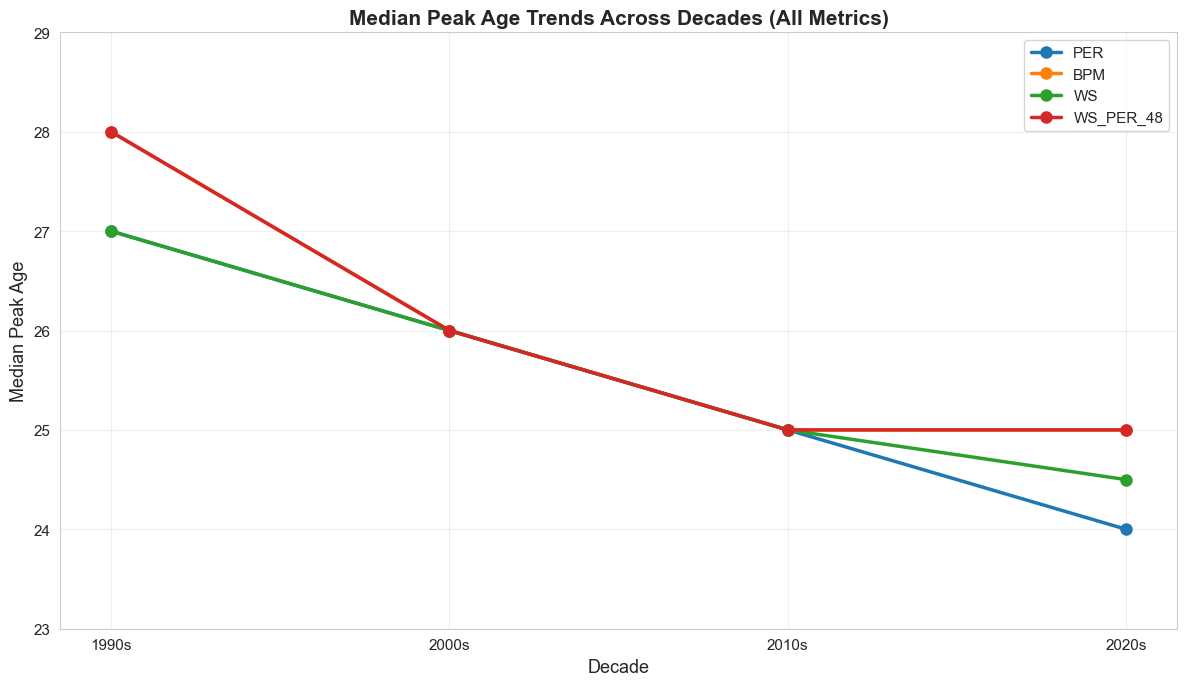

✓ Saved to ../figures/peak/peak_age_trends_all_decades.png


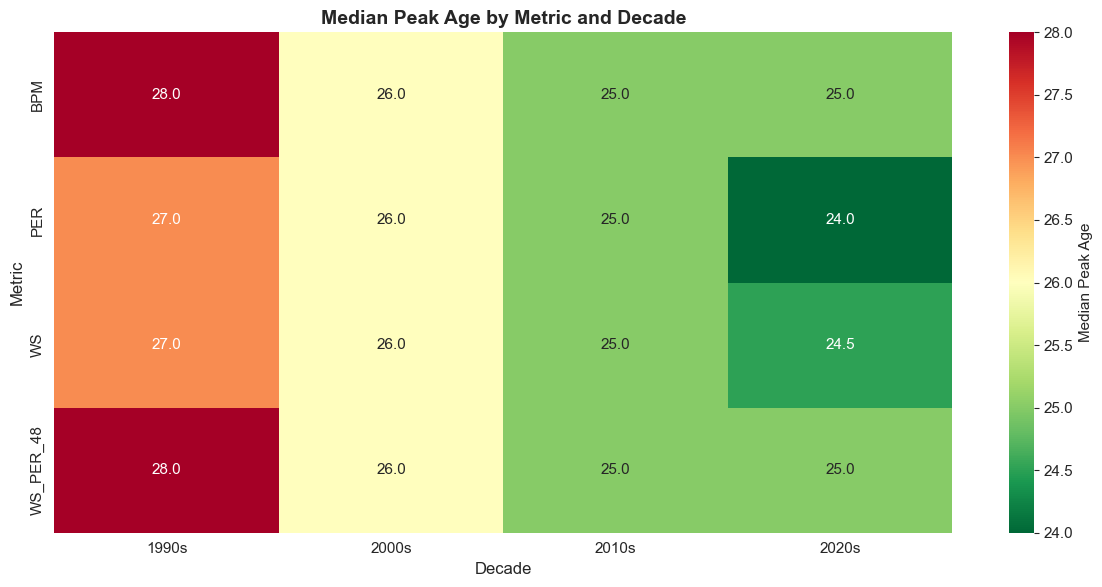

✓ Saved to ../figures/peak/peak_age_heatmap_all_decades.png

✓ Extended decade analysis complete


In [35]:
# Extended decade analysis for all available decades
print("=" * 80)
print("EXTENDED DECADE ANALYSIS - ALL DECADES")
print("=" * 80)

# Define extended decade assignment function
def assign_decade_extended(peak_year):
    """Assign decade based on peak year - extended to cover all eras"""
    if pd.isna(peak_year):
        return np.nan
    elif 1980 <= peak_year < 1990:
        return "1980s"
    elif 1990 <= peak_year < 2000:
        return "1990s"
    elif 2000 <= peak_year < 2010:
        return "2000s"
    elif 2010 <= peak_year < 2020:
        return "2010s"
    elif 2020 <= peak_year < 2030:
        return "2020s"
    else:
        return "Other"

# Apply extended decade columns for each metric
for metric in raw_metrics:
    peak_year_col = f'{metric}_peak_year'
    decade_col = f'{metric}_decade_ext'
    player_peaks_modern[decade_col] = player_peaks_modern[peak_year_col].apply(assign_decade_extended)

print("\n✓ Extended decade columns added")

# Check what decades we have
print("\nAvailable decades across all metrics:")
all_decades = set()
for metric in raw_metrics:
    decade_col = f'{metric}_decade_ext'
    decades = player_peaks_modern[decade_col].dropna().unique()
    all_decades.update(decades)
    print(f"  {metric}: {sorted([d for d in decades if d != 'Other'])}")

all_decades = sorted([d for d in all_decades if d != 'Other'])
print(f"\nAll unique decades: {all_decades}")

# Extended summary statistics by decade for each metric
extended_decade_summaries = []

for metric in raw_metrics:
    peak_age_col = f'{metric}_peak_age'
    decade_col = f'{metric}_decade_ext'
    
    for decade in all_decades:
        decade_data = player_peaks_modern[
            player_peaks_modern[decade_col] == decade
        ][peak_age_col].dropna()
        
        if len(decade_data) > 0:
            extended_decade_summaries.append({
                'metric': metric.upper(),
                'decade': decade,
                'count': len(decade_data),
                'median': decade_data.median(),
                'mean': decade_data.mean(),
                'std': decade_data.std(),
                'q1': decade_data.quantile(0.25),
                'q3': decade_data.quantile(0.75),
                'iqr': decade_data.quantile(0.75) - decade_data.quantile(0.25)
            })

extended_decade_summary = pd.DataFrame(extended_decade_summaries)

print("\n" + "=" * 80)
print("EXTENDED PEAK AGE SUMMARY BY DECADE (ALL AVAILABLE)")
print("=" * 80)
display(extended_decade_summary)

# Save to CSV
extended_decade_summary.to_csv(PEAK_DIR / "peak_age_summary_by_decade_extended.csv", index=False)
print(f"\n✓ Saved to {PEAK_DIR / 'peak_age_summary_by_decade_extended.csv'}")

# Detailed comparison across all decades
print("\n" + "=" * 80)
print("DECADE-TO-DECADE COMPARISON (ALL DECADES)")
print("=" * 80)

for metric in raw_metrics:
    peak_age_col = f'{metric}_peak_age'
    decade_col = f'{metric}_decade_ext'
    
    print(f"\n{metric.upper()}:")
    for decade in all_decades:
        data = player_peaks_modern[
            player_peaks_modern[decade_col] == decade
        ][peak_age_col].dropna()
        
        if len(data) > 0:
            print(f"  {decade}: n={len(data):4d}, median={data.median():.1f}, " +
                  f"mean={data.mean():.2f} ± {data.std():.2f}")

# Visualization: Trend across decades
print("\n" + "=" * 80)
print("GENERATING DECADE TREND VISUALIZATIONS")
print("=" * 80)

# Plot 1: Box plots by decade for BPM
fig, ax = plt.subplots(figsize=(14, 7))

bpm_decade_col = 'bpm_decade_ext'
box_data = [
    player_peaks_modern[player_peaks_modern[bpm_decade_col] == decade]['bpm_peak_age'].dropna()
    for decade in all_decades
]

bp = ax.boxplot(box_data, labels=all_decades, patch_artist=True,
                showmeans=True, meanline=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                meanprops=dict(color='green', linewidth=2, linestyle='--'))

ax.set_ylabel('Peak Age', fontsize=13)
ax.set_xlabel('Decade', fontsize=13)
ax.set_title('BPM Peak Age Trends Across Decades', fontsize=15, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Add count labels
for i, decade in enumerate(all_decades):
    count = len(box_data[i])
    ax.text(i+1, ax.get_ylim()[0] + 0.5, f'n={count}', 
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_by_decade_bpm_all.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_by_decade_bpm_all.png'}")

# Plot 2: Line plot showing median trends across decades
fig, ax = plt.subplots(figsize=(12, 7))

for metric in raw_metrics:
    decade_col = f'{metric}_decade_ext'
    peak_age_col = f'{metric}_peak_age'
    
    medians = []
    counts = []
    
    for decade in all_decades:
        data = player_peaks_modern[
            player_peaks_modern[decade_col] == decade
        ][peak_age_col].dropna()
        
        if len(data) > 0:
            medians.append(data.median())
            counts.append(len(data))
        else:
            medians.append(np.nan)
            counts.append(0)
    
    ax.plot(all_decades, medians, marker='o', markersize=8, linewidth=2.5, 
           label=metric.upper())

ax.set_xlabel('Decade', fontsize=13)
ax.set_ylabel('Median Peak Age', fontsize=13)
ax.set_title('Median Peak Age Trends Across Decades (All Metrics)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)
ax.set_ylim(23, 29)

plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_trends_all_decades.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_trends_all_decades.png'}")

# Plot 3: Heatmap of median peak ages
pivot_data = extended_decade_summary.pivot(index='metric', columns='decade', values='median')
pivot_data = pivot_data[all_decades]  # Ensure column order

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='RdYlGn_r', 
           center=26, vmin=24, vmax=28, square=False, ax=ax,
           cbar_kws={'label': 'Median Peak Age'})
ax.set_title('Median Peak Age by Metric and Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "peak_age_heatmap_all_decades.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {FIG_DIR / 'peak_age_heatmap_all_decades.png'}")

print("\n" + "=" * 80)
print("✓ Extended decade analysis complete")
print("=" * 80)